## Data Collection: Obtain a dataset with numerical features and a target variable for

### Data Exploration and Cleaning: Explore the dataset to understand its structure, handle missing values, and ensure data quality.

In [63]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [64]:
df = pd.read_csv('/Users/mahdeeahmed/Documents/Oasis Infobyte/MagicBricks.csv')
df.head()

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft
0,800.0,3,2.0,Semi-Furnished,Rohini Sector 25,1.0,6500000,Ready_to_move,New_Property,Builder_Floor,NaN
1,750.0,2,2.0,Semi-Furnished,"J R Designers Floors, Rohini Sector 24",1.0,5000000,Ready_to_move,New_Property,Apartment,6667.0
2,950.0,2,2.0,Furnished,"Citizen Apartment, Rohini Sector 13",1.0,15500000,Ready_to_move,Resale,Apartment,6667.0
3,600.0,2,2.0,Semi-Furnished,Rohini Sector 24,1.0,4200000,Ready_to_move,Resale,Builder_Floor,6667.0
4,650.0,2,2.0,Semi-Furnished,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,Ready_to_move,New_Property,Builder_Floor,6667.0


In [65]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1259.000000,1259.000000,1257.000000,1226.000000,1.259000e+03,1018.000000
mean,1466.452724,2.796664,2.556086,1.935563,2.130670e+07,15690.136542
std,1568.055040,0.954425,1.042220,6.279212,2.560115e+07,21134.738568
min,28.000000,1.000000,1.000000,1.000000,1.000000e+06,1259.000000
25%,800.000000,2.000000,2.000000,1.000000,5.700000e+06,6364.000000
50%,1200.000000,3.000000,2.000000,1.000000,1.420000e+07,11291.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.550000e+07,18000.000000
max,24300.000000,10.000000,7.000000,114.000000,2.400000e+08,183333.000000


In [66]:
df.isnull().sum()

Area             0
BHK              0
Bathroom         2
Furnishing       5
Locality         0
Parking         33
Price            0
Status           0
Transaction      0
Type             5
Per_Sqft       241
dtype: int64

In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1259 entries, 0 to 1258
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Area         1259 non-null   float64
 1   BHK          1259 non-null   int64  
 2   Bathroom     1257 non-null   float64
 3   Furnishing   1254 non-null   object 
 4   Locality     1259 non-null   object 
 5   Parking      1226 non-null   float64
 6   Price        1259 non-null   int64  
 7   Status       1259 non-null   object 
 8   Transaction  1259 non-null   object 
 9   Type         1254 non-null   object 
 10  Per_Sqft     1018 non-null   float64
dtypes: float64(4), int64(2), object(5)
memory usage: 108.3+ KB


In [68]:
### Removing null values with 0 in parking col.
df['Parking'].fillna(0,inplace=True)
df['Parking'].isnull().sum()

/var/folders/cx/tfcg_b5d0sd02g3ng3fjf7xh0000gn/T/ipykernel_12655/1017988215.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Parking'].fillna(0,inplace=True)


0

In [69]:
### Dropping all rows with no furnishing record.
df.dropna(subset=['Furnishing'],inplace=True)

In [70]:
###Removing null values with 0 in bathroom col.
# df['Bathroom'].fillna(0,inplace=True)

In [71]:
### Dropping all rows with no per_sqaure_ft record.
df.dropna(subset=['Per_Sqft'],inplace=True)

In [72]:
df.isnull().sum()

Area           0
BHK            0
Bathroom       0
Furnishing     0
Locality       0
Parking        0
Price          0
Status         0
Transaction    0
Type           0
Per_Sqft       0
dtype: int64

In [73]:
df.describe()

,Area,BHK,Bathroom,Parking,Price,Per_Sqft
count,1014.000000,1014.000000,1014.000000,1014.000000,1.014000e+03,1014.000000
mean,1501.920589,2.795858,2.571006,1.682446,2.221992e+07,15614.986193
std,1723.554333,0.964699,1.093997,3.212720,2.765378e+07,21089.529282
min,28.000000,1.000000,1.000000,0.000000,1.000000e+06,1259.000000
25%,765.000000,2.000000,2.000000,1.000000,5.147500e+06,6364.000000
50%,1150.000000,3.000000,2.000000,1.000000,1.400000e+07,11165.500000
75%,1700.000000,3.000000,3.000000,2.000000,2.737500e+07,18000.000000
max,24300.000000,7.000000,7.000000,39.000000,2.400000e+08,183333.000000


### Feature Selection: Identify relevant features that may contribute to the predictive model.

In [74]:
df.columns

Index(['Area', 'BHK', 'Bathroom', 'Furnishing', 'Locality', 'Parking', 'Price',
       'Status', 'Transaction', 'Type', 'Per_Sqft'],
      dtype='object')

In [75]:
df.groupby('Locality')['Price'].mean()

Locality
APL Builder Floor, Greater Kailash 1                                                                                                                                                                                                                                                                                                      6.000000e+07
Abhimanyu Apartments, Vasundhara Enclave                                                                                                                                                                                                                                                                                                  1.160000e+07
Abul Fazal Enclave Part 1, Okhla                                                                                                                                                                                                                                                                                 

In [76]:
df['Locality'].nunique()

310

In [77]:
locality_price_map = df.groupby('Locality')['Price'].mean().to_dict()
df['Locality_encoded'] = df['Locality'].map(locality_price_map)

,Area,BHK,Bathroom,Furnishing,Locality,Parking,Price,Status,Transaction,Type,Per_Sqft,Locality_encoded


In [78]:
new_df = pd.get_dummies(df,columns=['Furnishing','Status','Transaction','Type'],drop_first=True)
new_df.head()

,Area,BHK,Bathroom,Locality,Parking,Price,Per_Sqft,Locality_encoded,Furnishing_Semi-Furnished,Furnishing_Unfurnished,Status_Ready_to_move,Transaction_Resale,Type_Builder_Floor
1,750.0,2,2.0,"J R Designers Floors, Rohini Sector 24",1.0,5000000,6667.0,7.864516e+06,True,False,True,False,False
2,950.0,2,2.0,"Citizen Apartment, Rohini Sector 13",1.0,15500000,6667.0,1.550000e+07,False,False,True,True,False
3,600.0,2,2.0,Rohini Sector 24,1.0,4200000,6667.0,9.820000e+06,True,False,True,True,True
4,650.0,2,2.0,Rohini Sector 24 carpet area 650 sqft status R...,1.0,6200000,6667.0,6.200000e+06,True,False,True,False,True
5,1300.0,4,3.0,Rohini Sector 24,1.0,15500000,6667.0,9.820000e+06,True,False,True,False,True


In [79]:
new_df.isnull().sum()

Area                         0
BHK                          0
Bathroom                     0
Locality                     0
Parking                      0
Price                        0
Per_Sqft                     0
Locality_encoded             0
Furnishing_Semi-Furnished    0
Furnishing_Unfurnished       0
Status_Ready_to_move         0
Transaction_Resale           0
Type_Builder_Floor           0
dtype: int64

In [80]:
X = new_df[['Area', 'BHK', 'Bathroom', 'Parking','Per_Sqft',
       'Locality_encoded', 'Furnishing_Semi-Furnished',
       'Furnishing_Unfurnished', 'Status_Ready_to_move', 'Transaction_Resale',
       'Type_Builder_Floor']]
y= new_df['Price']

### Model Training: Implement linear regression using a machine learning library (e.g., Scikit-Learn).

In [81]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics


# X = new_df.drop(['Price','Locality'],axis=1)
# y = new_df['Price']

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=101)

In [84]:
# print(X.isna().sum())

lm = LinearRegression()
lm.fit(X_train,y_train)

LinearRegression()

### Model Evaluation: Evaluate the model's performance on a separate test dataset using

In [147]:
predictions = lm.predict(X_test)

### Residuals 

In [100]:
residuals = y_test - predictions

### Evaluation Score

In [149]:

MAE = metrics.mean_absolute_error(y_test , predictions)
MSE = metrics.mean_squared_error(y_test , predictions)
RMSE = np.sqrt(metrics.mean_squared_error(y_test , predictions))
	
	
	
print("Metrics Explained by variance score : ", round((metrics.explained_variance_score(y_test , predictions))*100,5),'%')

print(f"'MAE: '{MAE}")
print(f"'MSE: '{MSE}")
print(f"'RMSE: '{RMSE}")

Metrics Explained by variance score :  86.10351 %
'MAE: '6026208.784582783
'MSE: '105528188485426.55
'RMSE: '10272691.394441213


### Visualization: Create visualizations to illustrate the relationship between the predicted and actual values.


Text(0.5, 1.0, 'Test price vs Actual price')

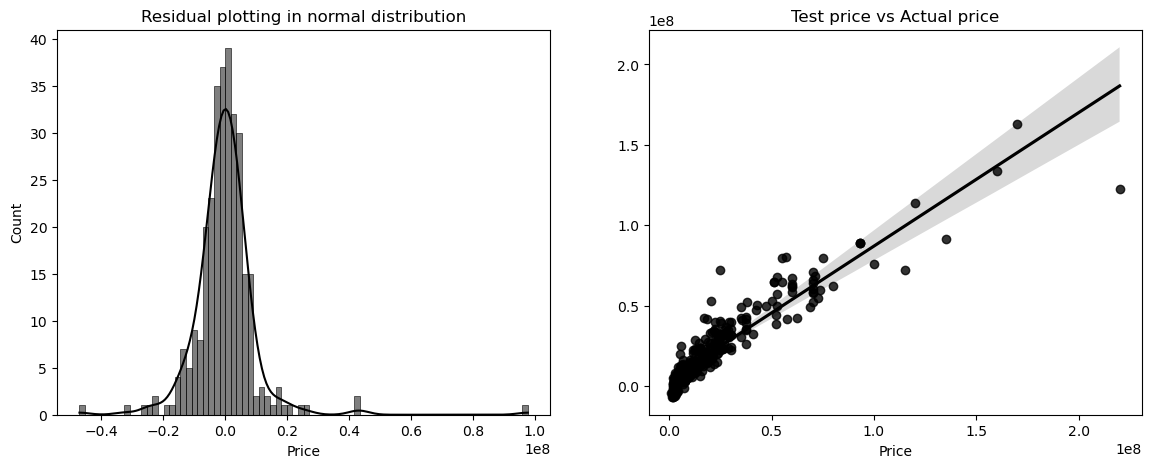

In [148]:
fig,ax = plt.subplots(1,2,figsize = [14,5])

sns.histplot(residuals,kde=True,bins=80,color="black",ax=ax[0])
ax[0].set_title('Residual plotting in normal distribution')

sns.regplot(x= y_test,y= predictions,ax = ax[1],color='black')
ax[1].set_title('Test price vs Actual price')



## Comment : The Evaluation score (Metrics Explained by variance score) is 86.10351 % which is a very good score but it could be improved further if we could get the actual locality data or if we could group them more accurately.